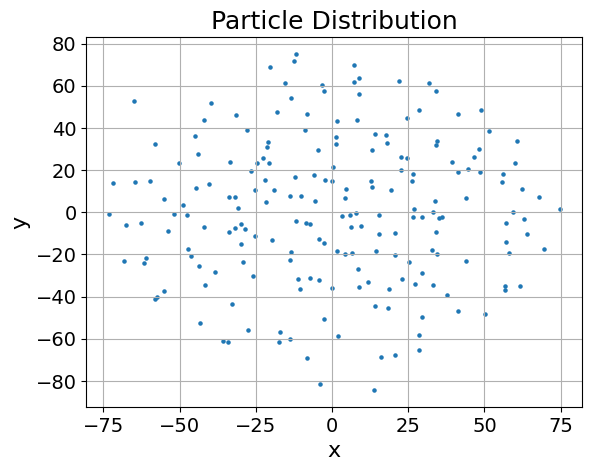

In [17]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("C:/Users/chowd/OneDrive/Documents/Yukawa/pos_5000.dat")

plt.scatter(data[:,0], data[:,1], s=5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Particle Distribution")
plt.grid()
plt.show()

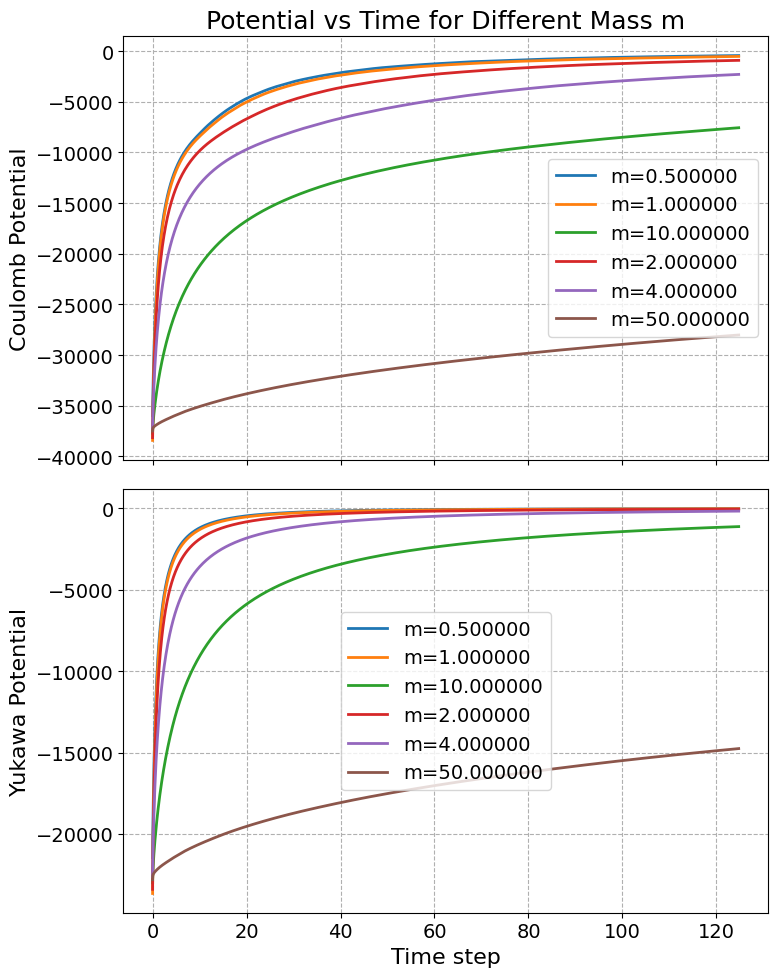

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import glob

files = sorted(glob.glob("energy_m_*.dat"))

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18
})

fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

for f in files:
    data = np.loadtxt(f)

    t  = data[:,0]
    KE = data[:,1]
    PE = data[:,2]
#     E  = data[:,3]

    # extract m value from filename
    label = f.split("_")[-1].replace(".dat", "")

    axes[0].plot(t, KE, label=f"m={label}", linewidth=2)
    axes[1].plot(t, PE, label=f"m={label}", linewidth=2)
#     axes[2].plot(t, E,  label=f"m={label}", linewidth=2)

# Labels
axes[0].set_ylabel("Coulomb Potential")
axes[1].set_ylabel("Yukawa Potential")
# axes[2].set_ylabel("Total E")
axes[1].set_xlabel("Time step")

axes[0].set_title("Potential vs Time for Different Mass m")

# Styling
for ax in axes:
    ax.grid(True, linestyle='--', alpha=1.0)
    ax.legend()

plt.tight_layout()
plt.savefig("energy_vs_m.png", dpi=300)
plt.show()

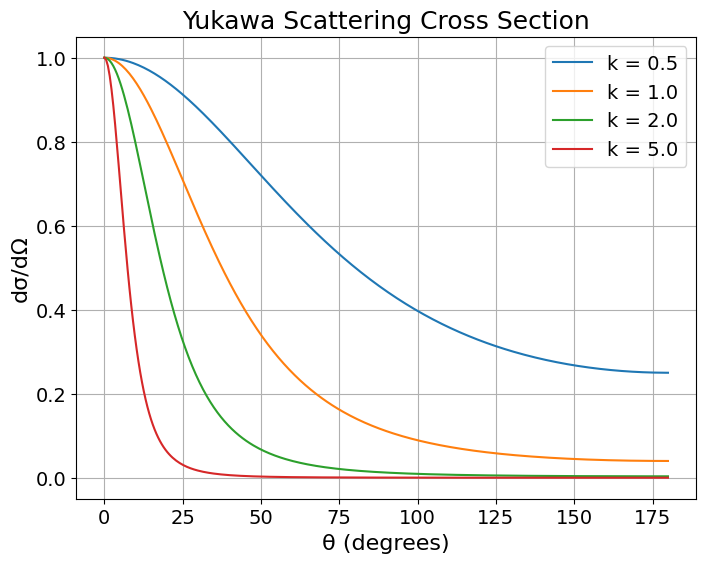

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os

k_values = [0.5, 1.0, 2.0, 5.0]

plt.figure(figsize=(8,6))

for k in k_values:
    filename = f"./scattering_k_{k:.6f}.dat"   # <-- FIX HERE

    if not os.path.exists(filename):
        print(f"Missing file: {filename}")
        continue

    data = np.loadtxt(filename)

    theta = data[:,0]
    ds = data[:,2]

    theta_deg = theta * 180 / np.pi

    plt.plot(theta_deg, ds, label=f"k = {k}")

plt.xlabel("θ (degrees)")
plt.ylabel("dσ/dΩ")
plt.title("Yukawa Scattering Cross Section")
plt.legend()
plt.grid()
plt.show()

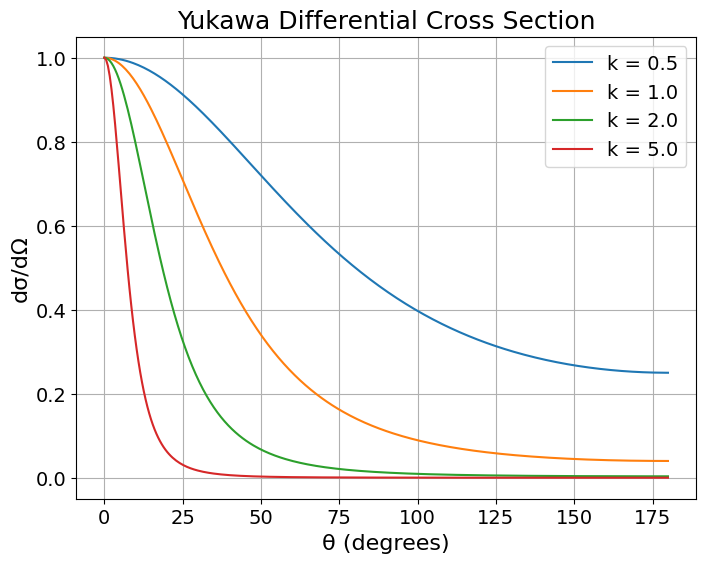

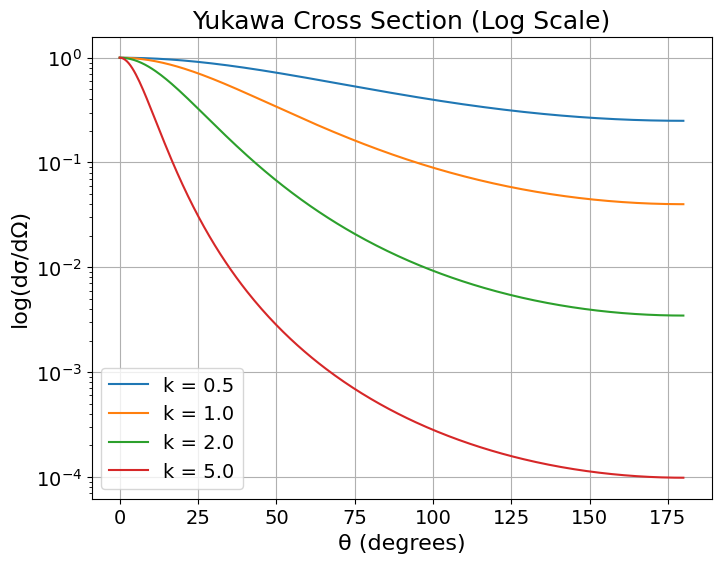

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

k_values = [0.5, 1.0, 2.0, 5.0]

# -----------------------------
# Linear plot
# -----------------------------
plt.figure(figsize=(8,6))

plotted = False

for k in k_values:
    filename = f"./scattering_k_{k:.6f}.dat"   # match C++ output

    if not os.path.exists(filename):
        print(f"Missing file: {filename}")
        continue

    data = np.loadtxt(filename)

    theta = data[:,0]
    ds = data[:,2]   # differential cross section

    theta_deg = theta * 180 / np.pi

    plt.plot(theta_deg, ds, label=f"k = {k}")
    plotted = True

if plotted:
    plt.xlabel("θ (degrees)")
    plt.ylabel("dσ/dΩ")
    plt.title("Yukawa Differential Cross Section")
    plt.legend()
    plt.grid()
    plt.show()
else:
    print("No data plotted. Check file paths.")


# -----------------------------
# LOG SCALE (IMPORTANT)
# -----------------------------
plt.figure(figsize=(8,6))

plotted = False

for k in k_values:
    filename = f"./scattering_k_{k:.6f}.dat"

    if not os.path.exists(filename):
        continue

    data = np.loadtxt(filename)

    theta = data[:,0]
    ds = data[:,2]

    theta_deg = theta * 180 / np.pi

    plt.semilogy(theta_deg, ds, label=f"k = {k}")
    plotted = True

if plotted:
    plt.xlabel("θ (degrees)")
    plt.ylabel("log(dσ/dΩ)")
    plt.title("Yukawa Cross Section (Log Scale)")
    plt.legend()
    plt.grid()
    plt.show()

In [6]:
import numpy as np
import os

k_values = [0.5, 1.0, 2.0, 5.0]

sigma_totals = []

for k in k_values:
    filename = f"./scattering_k_{k:.6f}.dat"

    if not os.path.exists(filename):
        print(f"Missing file: {filename}")
        continue

    data = np.loadtxt(filename)

    theta = data[:,0]
    ds = data[:,2]

    # integrand = ds * sin(theta)
    integrand = ds * np.sin(theta)

    # numerical integration (trapezoidal)
    sigma = 2 * np.pi * np.trapz(integrand, theta)

    sigma_totals.append((k, sigma))

    print(f"k = {k} → σ_total = {sigma:.6f}")

k = 0.5 → σ_total = 6.283118
k = 1.0 → σ_total = 2.513219
k = 2.0 → σ_total = 0.739146
k = 5.0 → σ_total = 0.124367


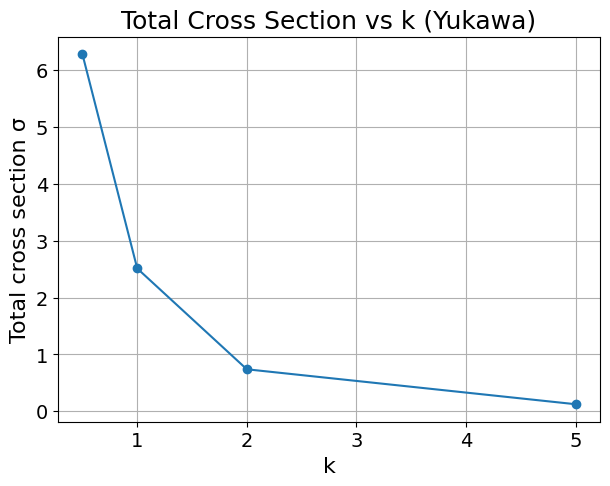

In [7]:
import matplotlib.pyplot as plt

k_plot = [x[0] for x in sigma_totals]
sigma_plot = [x[1] for x in sigma_totals]

plt.figure(figsize=(7,5))
plt.plot(k_plot, sigma_plot, marker='o')

plt.xlabel("k")
plt.ylabel("Total cross section σ")
plt.title("Total Cross Section vs k (Yukawa)")

plt.grid()
plt.show()

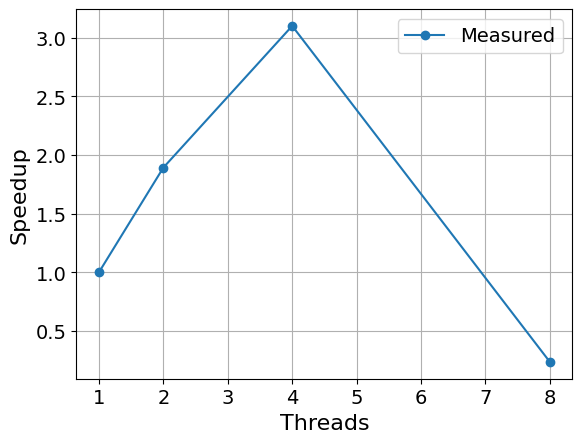

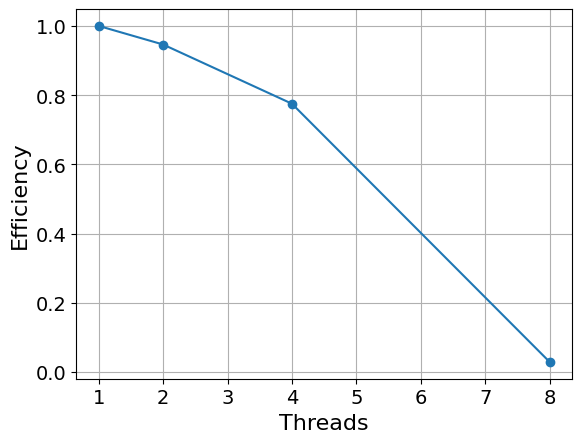

In [20]:
import numpy as np
import matplotlib.pyplot as plt


data = np.loadtxt("C:/Users/chowd/OneDrive/Documents/Yukawa/timing.dat")

threads = data[:,0]
time = data[:,1]

T1 = time[0]

speedup = T1 / time
efficiency = speedup / threads

# Speedup plot
plt.figure()
plt.plot(threads, speedup, 'o-', label="Measured")
# plt.plot(threads, threads, '--', label="Ideal")
plt.xlabel("Threads")
plt.ylabel("Speedup")
plt.legend()
plt.grid()
plt.savefig("speedup.png")

# Efficiency plot
plt.figure()
plt.plot(threads, efficiency, 'o-')
plt.xlabel("Threads")
plt.ylabel("Efficiency")
plt.grid()
plt.savefig("efficiency.png")

plt.show()